# Direction G: IQ-TREE phylogeny-informed AMR prediction

Dùng **IQ-TREE** để dựng cây tiến hóa từ ma trận core SNP, sau đó tạo đặc trưng lineage/phylogeny và kiểm tra xem việc thêm đặc trưng tiến hóa có cải thiện dự đoán AMR không.


Ý tưởng: kết quả Direction C cho thấy gen phụ là nguồn tín hiệu chính. Direction G thử bổ sung thông tin tiến hóa từ core SNP để xem có tăng hiệu năng không.

In [ ]:
from pathlib import Path

# =========================
# 1. Cấu hình
# =========================

REPO_URL = "https://github.com/347251369/Antimicrobial-resistance-prediction-in-Salmonella.git"
BASE_DIR = Path("/content/salmonella_direction_G_iqtree")
REPO_DIR = BASE_DIR / "Antimicrobial-resistance-prediction-in-Salmonella"
EXTRACT_DIR = BASE_DIR / "extracted"
OUT_DIR = BASE_DIR / "outputs"

DRUGS = ["AMP", "AUG", "AXO", "CHL", "FOX"]
N_REPEATS = 10
TEST_SIZE = 0.20
RANDOM_SEED_BASE = 42

# Số feature gen phụ được chọn trên train
K_ACCESSORY = 200

# Số SNP dùng để dựng cây. Tăng lên nếu Colab khỏe.
MAX_SNPS_FOR_TREE = 3000
MAX_CORE_SNP_PREFILTER = 15000
MAX_ACCESSORY_PREFILTER = 15000

# Số cụm lineage tạo từ cây IQ-TREE
LINEAGE_CLUSTER_KS = [5, 10, 20]

BASE_DIR.mkdir(parents=True, exist_ok=True)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("OUT_DIR:", OUT_DIR)

BASE_DIR: /content/salmonella_direction_G_iqtree
OUT_DIR: /content/salmonella_direction_G_iqtree/outputs


In [ ]:
# =========================
# 2. Import thư viện
# =========================

import os
import re
import json
import shutil
import subprocess
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

print("Import xong.")

Import xong.


In [ ]:
# =========================
# 3. Clone GitHub và cài tool
# =========================

if not REPO_DIR.exists():
    !git clone --depth 1 {REPO_URL} {REPO_DIR}
else:
    print("Repo đã tồn tại:", REPO_DIR)

# Cài công cụ giải nén và IQ-TREE nếu chưa có
!apt-get update -qq
!apt-get install -y -qq unrar p7zip-full iqtree > /dev/null 2>&1 || true

# Cài package Python cần cho đọc cây
try:
    import Bio
    print("Biopython đã có.")
except Exception:
    !pip -q install biopython

try:
    import scipy
    print("SciPy đã có.")
except Exception:
    !pip -q install scipy

# Kiểm tra tên lệnh IQ-TREE
def find_iqtree_cmd():
    for cmd in ["iqtree2", "iqtree"]:
        if shutil.which(cmd) is not None:
            return cmd
    return None

IQTREE_CMD = find_iqtree_cmd()
print("IQTREE_CMD =", IQTREE_CMD)

# Nếu apt không có iqtree, tải binary IQ-TREE2 Linux từ GitHub release.
# Cell này có thể cần internet trong Colab.
if IQTREE_CMD is None:
    print("Không thấy IQ-TREE từ apt. Thử tải binary IQ-TREE2...")
    !wget -q -O /content/iqtree2.tar.gz https://github.com/iqtree/iqtree2/releases/download/v2.3.6/iqtree-2.3.6-Linux.tar.gz
    !tar -xzf /content/iqtree2.tar.gz -C /content/
    # tìm binary
    candidates = list(Path('/content').rglob('iqtree2')) + list(Path('/content').rglob('iqtree'))
    candidates = [p for p in candidates if p.is_file()]
    if candidates:
        IQTREE_CMD = str(candidates[0])
    print("IQTREE_CMD =", IQTREE_CMD)

if IQTREE_CMD is None:
    raise RuntimeError("Không cài được IQ-TREE. Hãy chạy lại cell hoặc kiểm tra internet Colab.")

Cloning into '/content/salmonella_direction_G_iqtree/Antimicrobial-resistance-prediction-in-Salmonella'...
remote: Enumerating objects: 79, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 79 (delta 33), reused 54 (delta 25), pack-reused 0 (from 0)
Receiving objects: 100% (79/79), 2.95 MiB | 20.67 MiB/s, done.
Resolving deltas: 100% (33/33), done.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 37.1 MB/s eta 0:00:00
SciPy đã có.
IQTREE_CMD = iqtree2


In [ ]:
# =========================
# 4. Hàm tiện ích đọc dữ liệu
# =========================

def list_files(root, suffixes=None, max_items=100):
    root = Path(root)
    if not root.exists():
        return []
    files = []
    for p in root.rglob("*"):
        if p.is_file():
            if suffixes is None or p.suffix.lower() in suffixes:
                files.append(p)
    files = sorted(files, key=lambda x: x.stat().st_size if x.exists() else 0, reverse=True)
    return files[:max_items]


def read_table_flexible(path):
    path = Path(path)
    suffix = path.suffix.lower()
    print("Đang đọc:", path, "|", round(path.stat().st_size/1024/1024, 2), "MB")
    if suffix == ".csv":
        try:
            return pd.read_csv(path, low_memory=False)
        except Exception:
            return pd.read_csv(path, sep=None, engine="python")
    if suffix in [".tsv", ".txt"]:
        return pd.read_csv(path, sep=None, engine="python", low_memory=False)
    if suffix in [".xlsx", ".xls"]:
        return pd.read_excel(path)
    raise ValueError(f"Không hỗ trợ định dạng: {path}")


def extract_archive(archive_path, out_dir):
    archive_path = Path(archive_path)
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    if not archive_path.exists():
        print("Không thấy archive:", archive_path)
        return False
    print("Giải nén:", archive_path, "->", out_dir)
    code1 = os.system(f'unrar x -o+ "{archive_path}" "{out_dir}/"')
    if code1 == 0 and len(list(out_dir.rglob("*"))) > 0:
        return True
    code2 = os.system(f'7z x -y "{archive_path}" -o"{out_dir}"')
    if code2 == 0 and len(list(out_dir.rglob("*"))) > 0:
        return True
    print("CẢNH BÁO: giải nén thất bại hoặc archive rỗng.")
    return False


def find_largest_table(root):
    root = Path(root)
    candidates = list_files(root, suffixes=[".csv", ".tsv", ".txt", ".xlsx", ".xls"], max_items=30)
    if not candidates:
        return None
    print(f"Các bảng tìm thấy trong {root}:")
    for p in candidates[:10]:
        print(" -", p.name, round(p.stat().st_size/1024/1024, 2), "MB")
    return candidates[0]


def find_and_extract_named_archive(search_root, keywords, out_dir):
    search_root = Path(search_root)
    archives = []
    for pattern in ["*.rar", "*.zip", "*.7z"]:
        archives.extend(search_root.rglob(pattern))

    def score(p):
        s = str(p).lower()
        return sum(1 for kw in keywords if kw.lower() in s)

    archives = sorted(archives, key=lambda p: (score(p), p.stat().st_size), reverse=True)
    archives = [p for p in archives if score(p) > 0]
    if not archives:
        return None
    print("Archive phù hợp nhất:", archives[0])
    ok = extract_archive(archives[0], out_dir)
    return archives[0] if ok else None


def maybe_download_raw(url, out_path):
    out_path = Path(out_path)
    if out_path.exists() and out_path.stat().st_size > 0:
        print("Đã có:", out_path)
        return out_path
    print("Tải:", url)
    !wget -q -O "{out_path}" "{url}"
    print("Size:", out_path.stat().st_size if out_path.exists() else 0)
    return out_path


def make_unique(names, prefix="feature"):
    seen = Counter()
    out = []
    for i, n in enumerate(names):
        n = str(n) if str(n) != "nan" else f"{prefix}_{i}"
        if n in seen:
            seen[n] += 1
            out.append(f"{n}__dup{seen[n]}")
        else:
            seen[n] = 0
            out.append(n)
    return out

In [ ]:
# =========================
# 5. Đọc label theo từng thuốc từ data/csv
# =========================

def read_drug_label(drug):
    drug_dir = REPO_DIR / "data" / "csv" / drug
    label_path = drug_dir / f"{drug}_label.csv"
    if not label_path.exists():
        raise FileNotFoundError(label_path)
    ydf = pd.read_csv(label_path)
    if ydf.shape[1] == 1:
        y = ydf.iloc[:, 0]
    else:
        candidate = [c for c in ydf.columns if "label" in c.lower() or drug.lower() in c.lower()]
        y = ydf[candidate[0]] if candidate else ydf.iloc[:, -1]
    y = y.replace({"S":0, "I":0, "R":1, "s":0, "i":0, "r":1}).astype(int)
    y.index = [f"sample_{i}" for i in range(len(y))]
    return y

label_by_drug = {drug: read_drug_label(drug) for drug in DRUGS}

stats = []
for drug, y in label_by_drug.items():
    stats.append({
        "drug": drug,
        "n_samples": len(y),
        "n_resistant": int(y.sum()),
        "n_non_resistant": int((y==0).sum()),
        "resistant_rate": float(y.mean())
    })
data_stats_df = pd.DataFrame(stats)
display(data_stats_df)
labels_index = label_by_drug["AMP"].index

,drug,n_samples,n_resistant,n_non_resistant,resistant_rate
0,AMP,1167,199,968,0.170523
1,AUG,1167,139,1028,0.119109
2,AXO,1167,71,1096,0.060840
3,CHL,1167,126,1041,0.107969
4,FOX,1167,71,1096,0.060840


In [ ]:
# =========================
# 6. Định hướng và mã hóa ma trận feature
# =========================

def orient_feature_matrix_by_labels(df, labels_index, name):
    df = df.copy()
    n = len(labels_index)

    # Nếu có cột id/sample/name thì thử set làm index
    possible_id_cols = []
    for c in df.columns[:10]:
        cl = str(c).lower()
        if any(k in cl for k in ["sample", "accession", "biosample", "id", "name"]):
            possible_id_cols.append(c)
    for c in possible_id_cols:
        vals = df[c].astype(str).values
        overlap = len(set(vals).intersection(set(labels_index)))
        if overlap > 0:
            print(f"{name}: dùng cột {c} làm index, overlap={overlap}")
            df = df.set_index(c)
            return df

    # Trường hợp số hàng = số mẫu
    if df.shape[0] == n:
        print(f"{name}: số hàng = số mẫu ({n}). Căn theo thứ tự mẫu.")
        df.index = labels_index
        return df

    # Trường hợp số cột = số mẫu: matrix đang là feature × sample → transpose
    if df.shape[1] == n:
        print(f"{name}: số cột = số mẫu ({n}). Transpose feature × sample → sample × feature.")
        old_index = df.index
        df = df.T
        df.index = labels_index
        df.columns = make_unique([str(v) for v in old_index], prefix=f"{name}_feature")
        return df

    # Trường hợp cột đầu là tên feature, còn các cột sau là sample
    if df.shape[1] == n + 1:
        print(f"{name}: phát hiện 1 cột tên feature + {n} cột sample. Transpose.")
        feature_names = df.iloc[:, 0].astype(str).values
        mat = df.iloc[:, 1:].T
        mat.index = labels_index
        mat.columns = make_unique(feature_names, prefix=f"{name}_feature")
        return mat

    print(f"{name}: không nhận diện được orientation rõ ràng. Trả về nguyên dạng {df.shape}.")
    return df


def encode_feature_matrix(df, name, max_features_for_prefilter=None):
    df = df.copy()

    # Bỏ các cột object có vẻ là ID dài/chuỗi không mã hóa được
    drop_cols = []
    for c in df.columns:
        if df[c].dtype == "object":
            vals = df[c].dropna().astype(str).unique()
            # Nếu là presence/absence dạng chữ, map sang số
            lowvals = set(v.lower() for v in vals[:20])
            if lowvals.issubset({"0", "1", "true", "false", "present", "absent", "yes", "no", "a", "c", "g", "t", "n", "-"}):
                pass
            else:
                # vẫn thử convert numeric; nếu không được thì drop
                converted = pd.to_numeric(df[c], errors="coerce")
                if converted.notna().mean() < 0.95:
                    drop_cols.append(c)
                else:
                    df[c] = converted

    if drop_cols:
        print(f"{name}: bỏ {len(drop_cols)} cột dạng ID/text. Ví dụ:", drop_cols[:5])
        df = df.drop(columns=drop_cols)

    # Mã hóa base hoặc chữ thành số
    mapping = {
        "A":0, "C":1, "G":2, "T":3, "N":0, "-":0,
        "a":0, "c":1, "g":2, "t":3, "n":0,
        "present":1, "absent":0, "true":1, "false":0, "yes":1, "no":0,
        "Present":1, "Absent":0, "True":1, "False":0, "Yes":1, "No":0
    }
    for c in df.columns:
        if df[c].dtype == "object":
            df[c] = df[c].replace(mapping)
            df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)

    df = df.fillna(0)
    # ép numeric nhẹ
    df = df.apply(pd.to_numeric, errors="coerce").fillna(0)

    # Bỏ cột hằng
    variances = df.var(axis=0)
    keep = variances[variances > 0].index
    df = df[keep]

    if max_features_for_prefilter is not None and df.shape[1] > max_features_for_prefilter:
        top = df.var(axis=0).sort_values(ascending=False).head(max_features_for_prefilter).index
        df = df[top]
        print(f"{name}: giữ top {max_features_for_prefilter} feature theo phương sai để chạy nhẹ.")

    df.columns = make_unique(df.columns, prefix=name)
    print(f"{name}: encoded shape = {df.shape}")
    return df

In [ ]:
# =========================
# 7. Đọc ma trận gen phụ
# =========================

ACCESSORY_DIR = EXTRACT_DIR / "accessory_gene"
ACCESSORY_DIR.mkdir(parents=True, exist_ok=True)

accessory_table = find_largest_table(ACCESSORY_DIR)
if accessory_table is None:
    find_and_extract_named_archive(REPO_DIR, ["accessory", "gene", "existence", "roary"], ACCESSORY_DIR)
    accessory_table = find_largest_table(ACCESSORY_DIR)

if accessory_table is None:
    raw_url = "https://github.com/347251369/Antimicrobial-resistance-prediction-in-Salmonella/raw/main/results/Roary/accessory%20gene%20existence%20matrix.rar"
    archive_path = BASE_DIR / "accessory_gene_existence_matrix.rar"
    maybe_download_raw(raw_url, archive_path)
    extract_archive(archive_path, ACCESSORY_DIR)
    accessory_table = find_largest_table(ACCESSORY_DIR)

if accessory_table is None:
    raise FileNotFoundError("Không tìm được accessory gene matrix.")

accessory_raw = read_table_flexible(accessory_table)
accessory_oriented = orient_feature_matrix_by_labels(accessory_raw, labels_index, "accessory_gene")
X_accessory = encode_feature_matrix(accessory_oriented, "accessory_gene", max_features_for_prefilter=MAX_ACCESSORY_PREFILTER)
if X_accessory.shape[0] == len(labels_index):
    X_accessory.index = labels_index
print("X_accessory:", X_accessory.shape)
display(X_accessory.head())

Archive phù hợp nhất: /content/salmonella_direction_G_iqtree/Antimicrobial-resistance-prediction-in-Salmonella/results/Roary/accessory gene existence matrix.rar
Giải nén: /content/salmonella_direction_G_iqtree/Antimicrobial-resistance-prediction-in-Salmonella/results/Roary/accessory gene existence matrix.rar -> /content/salmonella_direction_G_iqtree/extracted/accessory_gene
Các bảng tìm thấy trong /content/salmonella_direction_G_iqtree/extracted/accessory_gene:
 - accessory gene existence matrix.csv 40.59 MB
Đang đọc: /content/salmonella_direction_G_iqtree/extracted/accessory_gene/accessory gene existence matrix.csv | 40.59 MB
accessory_gene: số hàng = số mẫu (1167). Căn theo thứ tự mẫu.
accessory_gene: bỏ 1 cột dạng ID/text. Ví dụ: ['Unnamed: 0']
accessory_gene: giữ top 15000 feature theo phương sai để chạy nhẹ.
accessory_gene: encoded shape = (1167, 15000)
X_accessory: (1167, 15000)


,J7C65_003890,ccdB,DK588_19620,JWS55_001066,D6I09_15270,ccdA,E6U56_20795,C2K47_20970,C2488_20440,DRI21_24680,D5T90_22780,LQN83_003980,group_3281,CE329_23785,KFT09_004614,GV134_13825,BWQ25_23105,CBU32_20390,C2485_21565,HX982_004100,GPA43_004124,psiB,CEW36_24625,KLW05_004653,repA,GIT43_19180,traX,C2F11_21375,traT,spvA,EJ247_21195,BWQ25_23435,GSC00_003820,group_5508,CW931_22560,LL873_004076,CHI38_20865,tap,traF,trbE,LKA01_003597,CHU49_20955,spvB,CKP58_21310,C8859_19160,MPS34_003964,traQ,traR,group_4097,IRQ96_003806,trbI,traG,traW,trbC,trbB,traV,group_1699,sopE2,traU,traN,...,GSC17_004627,GSC17_004628,GSC17_004626,GSC70_004761,GOQ46_004968,CHU14_16720,rbn,GSC70_004734,GVB94_004089,GVB94_004783,GSD57_002564,GSD57_002568,GSD57_002573,GVB94_004749,GSD57_002563,GOO02_004971,E3I96_08020,GVB94_005006,GOO02_004985,GOO02_004940,narI,H8V14_003085,emrA,group_19145,GSD50_004900,GSD50_004897,GSD50_004896,GSD50_004895,trmL,GSD50_004457,group_10615,group_10929,GSD50_004889,HBY45_003073,bsmA,GRX98_004918,GRX98_004906,GRX98_004821,GRX98_004916,GRX98_004817,GRX98_004908,GRX98_004919,GOQ53_000324,GOQ53_000325,GOQ53_001745,GOQ53_001632,GOQ53_000320,GOQ53_001747,GOQ53_003245,GOQ53_002776,GOQ53_002531,GOQ53_002775,GOQ53_002529,GOQ53_002528,GOQ53_002527,GOQ53_002526,GOQ53_003261,GOQ53_003288,GOQ53_004310,GOQ53_004576
sample_0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,1,1,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
sample_1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,1,1,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
sample_2,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,1,1,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
sample_3,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,1,1,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
sample_4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,1,1,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
# =========================
# 8. Đọc core SNP matrix — FIX lỗi không tìm thấy bảng và matrix bị ngược chiều
# =========================

CORE_DIR = EXTRACT_DIR / "core_snp"
CORE_DIR.mkdir(parents=True, exist_ok=True)

core_table = find_largest_table(CORE_DIR)
if core_table is None:
    find_and_extract_named_archive(REPO_DIR, ["core", "snp"], CORE_DIR)
    core_table = find_largest_table(CORE_DIR)

if core_table is None:
    raw_url = "https://github.com/347251369/Antimicrobial-resistance-prediction-in-Salmonella/raw/main/results/MAFFT/coreSNP.rar"
    archive_path = BASE_DIR / "coreSNP.rar"
    maybe_download_raw(raw_url, archive_path)
    extract_archive(archive_path, CORE_DIR)
    core_table = find_largest_table(CORE_DIR)

if core_table is None:
    raise FileNotFoundError("Không tìm được bảng core SNP sau khi giải nén/tải lại. Kiểm tra thư mục results/MAFFT/coreSNP.rar trong GitHub.")

core_raw = read_table_flexible(core_table)
core_oriented = orient_feature_matrix_by_labels(core_raw, labels_index, "core_snp")
X_core_snp_full = encode_feature_matrix(core_oriented, "core_snp", max_features_for_prefilter=MAX_CORE_SNP_PREFILTER)
if X_core_snp_full.shape[0] == len(labels_index):
    X_core_snp_full.index = labels_index
print("X_core_snp_full:", X_core_snp_full.shape)
display(X_core_snp_full.head())

Archive phù hợp nhất: /content/salmonella_direction_G_iqtree/Antimicrobial-resistance-prediction-in-Salmonella/results/MAFFT/core SNP matrix.rar
Giải nén: /content/salmonella_direction_G_iqtree/Antimicrobial-resistance-prediction-in-Salmonella/results/MAFFT/core SNP matrix.rar -> /content/salmonella_direction_G_iqtree/extracted/core_snp
Các bảng tìm thấy trong /content/salmonella_direction_G_iqtree/extracted/core_snp:
 - coreSNP.csv 281.73 MB
Đang đọc: /content/salmonella_direction_G_iqtree/extracted/core_snp/coreSNP.csv | 281.73 MB
core_snp: phát hiện 1 cột tên feature + 1167 cột sample. Transpose.
core_snp: giữ top 15000 feature theo phương sai để chạy nhẹ.
core_snp: encoded shape = (1167, 15000)
X_core_snp_full: (1167, 15000)


,323560,323593,323608,323590,324038,324110,323943,323942,323681,202669,202783,202654,956337,309675,827605,827554,831106,831212,831164,831170,831161,831296,831149,2470244,1471664,3295450,323958,323984,323786,324350,323645,323844,324403,323885,324195,323873,323996,324123,324155,323860,2084234,1623070,2212067,697311,3106017,323967,324031,531561,531575,202648,1788618,202618,272351,3274330,3086787,1054799,3029680,1898055,76533,76530,...,2035210,2914871,1224123,3235278,3147375,1080406,500672,74331,1139191,2355107,1936760,3152170,3165877,831870,3021495,1667055,116542,875947,1371813,2705152,2357159,364463,1311274,145644,662120,3252761,1815433,2970750,129826,1814764,264617,3081436,662151,397832,466345,467003,1202907,3033129,3079287,1800137,1197673,225391,725851,1839893,3252674,1840490,381638,1839686,1922501,1924664,1347351,3279992,1404900,73083,112117,2339268,608509,324657,2979018,1200857
sample_0,4,4,4,4,4,4,4,4,4,4,4,4,4,0,4,4,0,0,0,0,0,0,0,4,4,4,3,3,3,3,3,3,3,3,3,3,3,3,3,3,4,1,4,1,4,3,3,0,0,3,4,3,1,4,1,4,4,3,4,4,...,4,4,4,4,3,4,4,4,4,4,4,4,4,4,2,2,2,4,2,4,4,4,2,4,2,4,2,4,2,2,3,4,2,4,4,4,4,3,4,4,4,2,4,2,3,2,4,2,4,2,4,4,3,4,4,2,2,2,4,4
sample_1,4,4,4,4,4,4,4,4,4,4,4,4,4,0,4,4,0,0,0,0,0,0,0,4,4,4,3,3,3,3,3,3,3,3,3,3,3,3,3,3,4,1,4,1,4,3,3,0,0,3,4,3,1,4,1,4,4,3,4,4,...,4,4,4,4,3,4,4,4,4,4,4,4,4,4,2,2,2,4,2,4,4,4,2,4,2,4,2,4,2,2,3,4,2,4,4,4,4,3,4,4,4,2,4,2,3,2,4,2,4,2,4,4,3,4,4,2,2,2,4,4
sample_2,4,4,4,4,4,4,4,4,4,4,4,4,4,0,4,4,0,0,0,0,0,0,0,4,4,4,3,3,3,3,3,3,3,3,3,3,3,3,3,3,4,1,4,1,4,3,3,0,0,3,4,3,1,4,1,4,4,3,4,4,...,4,4,4,4,3,4,4,4,4,4,4,4,4,4,2,2,2,4,2,4,4,4,2,4,2,4,2,4,2,2,3,4,2,4,4,4,4,3,4,4,4,2,4,2,3,2,4,2,4,2,4,4,3,4,4,2,2,2,4,4
sample_3,0,0,0,0,0,0,0,0,0,0,0,0,4,0,4,4,0,0,0,0,0,0,0,4,4,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,4,1,4,1,0,0,0,0,0,1,0,4,4,4,4,1,3,4,4,...,4,4,4,4,3,4,4,4,4,4,4,4,4,4,2,2,2,4,2,4,4,4,2,4,2,4,2,4,2,2,3,4,2,4,4,4,4,3,4,4,4,2,4,2,3,2,4,2,4,2,4,4,3,4,4,2,2,2,4,4
sample_4,4,4,4,4,4,4,4,4,4,4,4,4,4,0,4,4,0,0,0,0,0,0,0,4,4,4,3,3,3,3,3,3,3,3,3,3,3,3,3,3,4,1,4,1,4,3,3,0,0,3,4,3,4,4,4,4,4,3,4,4,...,4,4,4,4,3,4,4,4,4,4,4,4,4,4,2,2,2,4,2,4,4,4,2,4,2,4,2,4,2,2,3,4,2,4,4,4,4,3,4,4,4,2,4,2,3,2,4,2,4,2,4,4,3,4,4,2,2,2,4,4


In [ ]:
# =========================
# 9. Tạo alignment FASTA từ core SNP để chạy IQ-TREE
# =========================

def numeric_to_dna_value(v):
    # Chuyển numeric/categorical thành base giả để IQ-TREE đọc được.
    # Nếu dữ liệu là 0/1/2/3 thì map sang A/C/G/T. Nếu đã là base thì giữ.
    if pd.isna(v):
        return "N"
    s = str(v).strip()
    if s in ["A", "C", "G", "T", "N", "-"]:
        return "N" if s == "-" else s
    if s in ["a", "c", "g", "t", "n"]:
        return s.upper()
    try:
        x = int(float(s))
        return {0:"A", 1:"C", 2:"G", 3:"T"}.get(x % 4, "N")
    except Exception:
        return "N"


def build_snp_alignment(X_core, max_snps=3000, out_fasta=None):
    X = X_core.copy()
    # chọn SNP có phương sai cao để cây chạy nhanh hơn
    if X.shape[1] > max_snps:
        cols = X.var(axis=0).sort_values(ascending=False).head(max_snps).index
        X = X[cols]
    print("Alignment matrix:", X.shape)

    out_fasta = Path(out_fasta)
    with open(out_fasta, "w") as f:
        for sample, row in X.iterrows():
            seq = ''.join(numeric_to_dna_value(v) for v in row.values)
            f.write(f">{sample}\n")
            # wrap 80 chars
            for j in range(0, len(seq), 80):
                f.write(seq[j:j+80] + "\n")
    return out_fasta, X

alignment_fasta = OUT_DIR / "coreSNP_for_iqtree.fasta"
alignment_fasta, X_core_for_tree = build_snp_alignment(X_core_snp_full, MAX_SNPS_FOR_TREE, alignment_fasta)
print("FASTA:", alignment_fasta)
print("Size:", round(alignment_fasta.stat().st_size/1024/1024, 2), "MB")


Alignment matrix: (1167, 3000)
FASTA: /content/salmonella_direction_G_iqtree/outputs/coreSNP_for_iqtree.fasta
Size: 3.39 MB


In [ ]:
# =========================
# 10. Chạy IQ-TREE
# =========================

IQTREE_WORK = OUT_DIR / "iqtree_run"
IQTREE_WORK.mkdir(parents=True, exist_ok=True)

# copy fasta vào workdir để file output gọn
work_fasta = IQTREE_WORK / alignment_fasta.name
shutil.copy(alignment_fasta, work_fasta)

treefile = Path(str(work_fasta) + ".treefile")

if not treefile.exists():
    print("Chạy IQ-TREE. Cell này có thể mất vài phút.")
    cmd = [str(IQTREE_CMD), "-s", str(work_fasta), "-m", "GTR+G", "-nt", "2", "-fast", "-redo", "-quiet"]
    print("CMD:", " ".join(cmd))
    result = subprocess.run(cmd, cwd=str(IQTREE_WORK), stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    print(result.stdout[-3000:])
else:
    print("Đã có treefile:", treefile)

if not treefile.exists():
    # Một số version tạo tên khác
    candidates = list(IQTREE_WORK.glob("*.treefile")) + list(IQTREE_WORK.glob("*.tree"))
    print("Candidates:", candidates)
    if candidates:
        treefile = candidates[0]

if not treefile.exists():
    raise FileNotFoundError("IQ-TREE không tạo được treefile.")

print("Treefile:", treefile)
print(open(treefile).read()[:500])

Chạy IQ-TREE. Cell này có thể mất vài phút.
CMD: iqtree2 -s /content/salmonella_direction_G_iqtree/outputs/iqtree_run/coreSNP_for_iqtree.fasta -m GTR+G -nt 2 -fast -redo -quiet

Treefile: /content/salmonella_direction_G_iqtree/outputs/iqtree_run/coreSNP_for_iqtree.fasta.treefile
(sample_0:0.0022210617,(((((((((((sample_1:0.0052970158,(sample_62:0.0007379635,sample_67:0.0007380469):0.0014926296):0.0021968564,(sample_562:0.0000010000,sample_582:0.0007339817):0.0000010000):0.0007328568,sample_266:0.0014712603):0.0022086052,sample_214:0.0000025823):0.0044334239,((((sample_8:0.0000010000,(((((sample_51:0.0088816536,sample_253:0.0000020253):0.0014699217,sample_234:0.0149169541):0.0000023774,(sample_269:0.0000010000,sample_271:0.0000010000):0.0000010000):0.0007348651,sample_25


In [ ]:
# =========================
# 11. Trích đặc trưng phylogeny/lineage từ cây IQ-TREE
# =========================

from Bio import Phylo
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster

tree = Phylo.read(str(treefile), "newick")
terminals = tree.get_terminals()
sample_names = [t.name for t in terminals]
print("Số tips trong cây:", len(sample_names))
print("Ví dụ tips:", sample_names[:5])

# Đảm bảo cây có đủ sample_0...sample_1166
missing = set(labels_index) - set(sample_names)
if missing:
    print("CẢNH BÁO: thiếu tips so với label:", len(missing), "ví dụ", list(missing)[:5])

# Tính root-to-tip length
root_to_tip = {}
for t in terminals:
    try:
        root_to_tip[t.name] = tree.distance(t)
    except Exception:
        root_to_tip[t.name] = 0.0

# Tính patristic distance matrix. 1167x1167 vẫn chạy được.
valid_samples = [s for s in labels_index if s in set(sample_names)]
print("Valid samples:", len(valid_samples))

# Cache terminals by name
term_by_name = {t.name: t for t in terminals}
N = len(valid_samples)
dist_mat = np.zeros((N, N), dtype=np.float32)
for i in range(N):
    ti = term_by_name[valid_samples[i]]
    for j in range(i+1, N):
        d = tree.distance(ti, term_by_name[valid_samples[j]])
        dist_mat[i, j] = dist_mat[j, i] = d

# PCA/MDS-like features từ khoảng cách cây
pca = PCA(n_components=5, random_state=42)
phylo_pcs = pca.fit_transform(dist_mat)

X_phylo = pd.DataFrame(index=valid_samples)
X_phylo["root_to_tip"] = [root_to_tip.get(s, 0.0) for s in valid_samples]
for k in range(phylo_pcs.shape[1]):
    X_phylo[f"tree_distance_PC{k+1}"] = phylo_pcs[:, k]

# Cluster lineage từ patristic distance
condensed = squareform(dist_mat, checks=False)
Z = linkage(condensed, method="average")
for k in LINEAGE_CLUSTER_KS:
    clusters = fcluster(Z, t=k, criterion="maxclust")
    dummies = pd.get_dummies(clusters, prefix=f"iqtree_cluster{k}")
    dummies.index = valid_samples
    X_phylo = pd.concat([X_phylo, dummies], axis=1)

print("X_phylo:", X_phylo.shape)
display(X_phylo.head())

X_phylo.to_csv(OUT_DIR / "iqtree_phylogeny_features.csv")

Số tips trong cây: 1167
Ví dụ tips: ['sample_0', 'sample_1', 'sample_62', 'sample_67', 'sample_562']
Valid samples: 1167
X_phylo: (1167, 41)


,root_to_tip,tree_distance_PC1,tree_distance_PC2,tree_distance_PC3,tree_distance_PC4,tree_distance_PC5,iqtree_cluster5_1,iqtree_cluster5_2,iqtree_cluster5_3,iqtree_cluster5_4,iqtree_cluster5_5,iqtree_cluster10_1,iqtree_cluster10_2,iqtree_cluster10_3,iqtree_cluster10_4,iqtree_cluster10_5,iqtree_cluster10_6,iqtree_cluster10_7,iqtree_cluster10_8,iqtree_cluster10_9,iqtree_cluster10_10,iqtree_cluster20_1,iqtree_cluster20_2,iqtree_cluster20_3,iqtree_cluster20_4,iqtree_cluster20_5,iqtree_cluster20_6,iqtree_cluster20_7,iqtree_cluster20_8,iqtree_cluster20_9,iqtree_cluster20_10,iqtree_cluster20_11,iqtree_cluster20_12,iqtree_cluster20_13,iqtree_cluster20_14,iqtree_cluster20_15,iqtree_cluster20_16,iqtree_cluster20_17,iqtree_cluster20_18,iqtree_cluster20_19,iqtree_cluster20_20
sample_0,0.002221,-2.275379,3.915061,-0.349998,0.729818,0.029394,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
sample_1,0.019280,-1.822244,3.990155,-0.296812,0.732134,0.127863,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
sample_2,0.046432,-2.273412,3.803749,-0.313759,0.623616,0.009453,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
sample_3,0.292439,-2.215222,-3.257427,-0.092395,0.113490,-0.179120,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
sample_4,0.181198,-1.582976,2.469953,0.422327,-1.442484,-0.138214,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
# =========================
# 12. Hàm load ready 50 features của bài báo
# =========================

def load_ready_50_features(drug):
    drug_dir = REPO_DIR / "data" / "csv" / drug
    X = pd.read_csv(drug_dir / "gene.csv")
    # bỏ cột text nếu có
    X2 = X.copy()
    for c in list(X2.columns):
        if X2[c].dtype == "object":
            conv = pd.to_numeric(X2[c], errors="coerce")
            if conv.notna().mean() >= 0.95:
                X2[c] = conv.fillna(0)
            else:
                X2 = X2.drop(columns=[c])
    X2 = X2.fillna(0)
    X2.index = [f"sample_{i}" for i in range(len(X2))]
    X2.columns = make_unique(X2.columns, prefix=f"ready_{drug}")
    return X2

def select_kbest_train_only(X_train, y_train, X_test, k):
    k = min(k, X_train.shape[1])
    selector = SelectKBest(score_func=chi2, k=k)
    # chi2 cần non-negative
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    selector.fit(X_train_scaled, y_train)
    cols = X_train.columns[selector.get_support()]
    X_train_sel = pd.DataFrame(selector.transform(X_train_scaled), index=X_train.index, columns=cols)
    X_test_sel = pd.DataFrame(selector.transform(X_test_scaled), index=X_test.index, columns=cols)
    return X_train_sel, X_test_sel, list(cols)

def eval_metrics(y_true, pred, prob):
    out = {
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "f1": f1_score(y_true, pred, zero_division=0),
        "auprc": average_precision_score(y_true, prob),
    }
    try:
        out["auroc"] = roc_auc_score(y_true, prob)
    except Exception:
        out["auroc"] = np.nan
    return out

In [ ]:
# =========================
# 13. Đánh giá Direction G
# =========================

def evaluate_drug_direction_G(drug, n_repeats=N_REPEATS):
    y = label_by_drug[drug].copy()

    # Các representation cố định theo sample
    X_ready = load_ready_50_features(drug)
    X_access = X_accessory.copy()
    X_phy = X_phylo.copy()

    # chỉ dùng sample có trong cả phylo và label
    common = y.index.intersection(X_phy.index)
    y = y.loc[common]
    X_ready = X_ready.loc[common]
    X_access = X_access.loc[common]
    X_phy = X_phy.loc[common]

    rows = []
    selected_counter = Counter()

    for rep in range(n_repeats):
        seed = RANDOM_SEED_BASE + rep
        idx_train, idx_test = train_test_split(
            y.index, test_size=TEST_SIZE, random_state=seed, stratify=y
        )
        y_train, y_test = y.loc[idx_train], y.loc[idx_test]

        # 1 ready 50
        reps = {}
        reps["ready_50_features_from_paper"] = (X_ready.loc[idx_train], X_ready.loc[idx_test], [])

        # 2 accessory 200 train-only
        Xa_train, Xa_test, sel = select_kbest_train_only(X_access.loc[idx_train], y_train, X_access.loc[idx_test], K_ACCESSORY)
        reps["accessory_train_only_200"] = (Xa_train, Xa_test, sel)
        for f in sel:
            selected_counter[(drug, f)] += 1

        # 3 IQ-TREE phylogeny features only
        reps["iqtree_phylogeny_features"] = (X_phy.loc[idx_train], X_phy.loc[idx_test], [])

        # 4 accessory + IQ-TREE
        Xcomb_train = pd.concat([Xa_train.reset_index(drop=True), X_phy.loc[idx_train].reset_index(drop=True)], axis=1)
        Xcomb_test = pd.concat([Xa_test.reset_index(drop=True), X_phy.loc[idx_test].reset_index(drop=True)], axis=1)
        Xcomb_train.index = idx_train
        Xcomb_test.index = idx_test
        reps["accessory_200_plus_iqtree"] = (Xcomb_train, Xcomb_test, sel)

        for rep_name, (Xtr, Xte, sel_feats) in reps.items():
            # model đơn giản chính: Logistic Regression balanced
            model = LogisticRegression(max_iter=10000, class_weight="balanced", solver="lbfgs")
            model.fit(Xtr, y_train)
            prob = model.predict_proba(Xte)[:, 1]
            pred = (prob >= 0.5).astype(int)
            metrics = eval_metrics(y_test, pred, prob)
            rows.append({
                "drug": drug,
                "repeat": rep,
                "representation": rep_name,
                "model": "LogisticRegression_balanced",
                "n_train": len(y_train),
                "n_test": len(y_test),
                "n_test_resistant": int(y_test.sum()),
                **metrics
            })

    return pd.DataFrame(rows), selected_counter

all_rows = []
all_selected = Counter()
for drug in DRUGS:
    print("\n" + "="*80)
    print("Đang chạy", drug)
    print("="*80)
    df_drug, counter_drug = evaluate_drug_direction_G(drug)
    all_rows.append(df_drug)
    all_selected.update(counter_drug)

results_raw = pd.concat(all_rows, ignore_index=True)
results_raw.to_csv(OUT_DIR / "direction_G_raw_results.csv", index=False)
display(results_raw.head())


Đang chạy AMP

Đang chạy AUG

Đang chạy AXO

Đang chạy CHL

Đang chạy FOX


,drug,repeat,representation,model,n_train,n_test,n_test_resistant,balanced_accuracy,f1,auprc,auroc
0,AMP,0,ready_50_features_from_paper,LogisticRegression_balanced,933,234,40,0.954768,0.925000,0.956243,0.978737
1,AMP,0,accessory_train_only_200,LogisticRegression_balanced,933,234,40,0.937113,0.888889,0.925372,0.964111
2,AMP,0,iqtree_phylogeny_features,LogisticRegression_balanced,933,234,40,0.775258,0.577320,0.732227,0.859343
3,AMP,0,accessory_200_plus_iqtree,LogisticRegression_balanced,933,234,40,0.927191,0.886076,0.937198,0.976418
4,AMP,1,ready_50_features_from_paper,LogisticRegression_balanced,933,234,40,0.984923,0.975000,0.991129,0.997165


In [ ]:
# =========================
# 14. Tổng hợp kết quả
# =========================

summary = results_raw.groupby(["drug", "representation", "model"]).agg(
    balanced_accuracy_mean=("balanced_accuracy", "mean"),
    balanced_accuracy_std=("balanced_accuracy", "std"),
    f1_mean=("f1", "mean"),
    f1_std=("f1", "std"),
    auroc_mean=("auroc", "mean"),
    auroc_std=("auroc", "std"),
    auprc_mean=("auprc", "mean"),
    auprc_std=("auprc", "std"),
    n_test_resistant_mean=("n_test_resistant", "mean"),
).reset_index()

summary.to_csv(OUT_DIR / "direction_G_summary.csv", index=False)
display(summary.sort_values(["drug", "balanced_accuracy_mean"], ascending=[True, False]))

best_bacc = summary.sort_values("balanced_accuracy_mean", ascending=False).groupby("drug").head(1).sort_values("drug")
best_auprc = summary.sort_values("auprc_mean", ascending=False).groupby("drug").head(1).sort_values("drug")

print("Best by balanced accuracy")
display(best_bacc)
print("Best by AUPRC")
display(best_auprc)

,drug,representation,model,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,auroc_mean,auroc_std,auprc_mean,auprc_std,n_test_resistant_mean
3,AMP,ready_50_features_from_paper,LogisticRegression_balanced,0.963595,0.016751,0.943307,0.023463,0.985445,0.009971,0.967191,0.016901,40.0
1,AMP,accessory_train_only_200,LogisticRegression_balanced,0.922590,0.026223,0.870249,0.035542,0.951160,0.027432,0.916421,0.037793,40.0
0,AMP,accessory_200_plus_iqtree,LogisticRegression_balanced,0.918325,0.024571,0.863837,0.032216,0.951031,0.024701,0.920164,0.028487,40.0
2,AMP,iqtree_phylogeny_features,LogisticRegression_balanced,0.824961,0.030740,0.630915,0.035372,0.884626,0.026181,0.751989,0.035326,40.0
5,AUG,accessory_train_only_200,LogisticRegression_balanced,0.974046,0.020451,0.935440,0.021500,0.981293,0.028358,0.952147,0.036732,28.0
7,AUG,ready_50_features_from_paper,LogisticRegression_balanced,0.969261,0.025876,0.923519,0.028924,0.979577,0.022312,0.930146,0.039366,28.0
4,AUG,accessory_200_plus_iqtree,LogisticRegression_balanced,0.967874,0.019729,0.934730,0.029323,0.977583,0.026751,0.946153,0.035693,28.0
6,AUG,iqtree_phylogeny_features,LogisticRegression_balanced,0.839719,0.026388,0.551268,0.034627,0.875217,0.031970,0.608948,0.074971,28.0
11,AXO,ready_50_features_from_paper,LogisticRegression_balanced,0.977208,0.024805,0.957060,0.032982,0.999188,0.001052,0.990918,0.011816,14.0
9,AXO,accessory_train_only_200,LogisticRegression_balanced,0.974091,0.029180,0.959741,0.032892,0.992516,0.015491,0.983586,0.029783,14.0


Best by balanced accuracy


,drug,representation,model,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,auroc_mean,auroc_std,auprc_mean,auprc_std,n_test_resistant_mean
3,AMP,ready_50_features_from_paper,LogisticRegression_balanced,0.963595,0.016751,0.943307,0.023463,0.985445,0.009971,0.967191,0.016901,40.0
5,AUG,accessory_train_only_200,LogisticRegression_balanced,0.974046,0.020451,0.935440,0.021500,0.981293,0.028358,0.952147,0.036732,28.0
11,AXO,ready_50_features_from_paper,LogisticRegression_balanced,0.977208,0.024805,0.957060,0.032982,0.999188,0.001052,0.990918,0.011816,14.0
13,CHL,accessory_train_only_200,LogisticRegression_balanced,0.932823,0.023249,0.880058,0.026865,0.944402,0.037566,0.903223,0.047989,25.0
17,FOX,accessory_train_only_200,LogisticRegression_balanced,0.956006,0.022695,0.938213,0.039959,0.974789,0.017334,0.949064,0.034573,14.0


Best by AUPRC


,drug,representation,model,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,auroc_mean,auroc_std,auprc_mean,auprc_std,n_test_resistant_mean
3,AMP,ready_50_features_from_paper,LogisticRegression_balanced,0.963595,0.016751,0.943307,0.023463,0.985445,0.009971,0.967191,0.016901,40.0
5,AUG,accessory_train_only_200,LogisticRegression_balanced,0.974046,0.020451,0.935440,0.021500,0.981293,0.028358,0.952147,0.036732,28.0
11,AXO,ready_50_features_from_paper,LogisticRegression_balanced,0.977208,0.024805,0.957060,0.032982,0.999188,0.001052,0.990918,0.011816,14.0
15,CHL,ready_50_features_from_paper,LogisticRegression_balanced,0.930517,0.025394,0.852428,0.038707,0.944976,0.028780,0.912176,0.037641,25.0
19,FOX,ready_50_features_from_paper,LogisticRegression_balanced,0.955325,0.022470,0.928151,0.039308,0.979578,0.028113,0.963540,0.031577,14.0


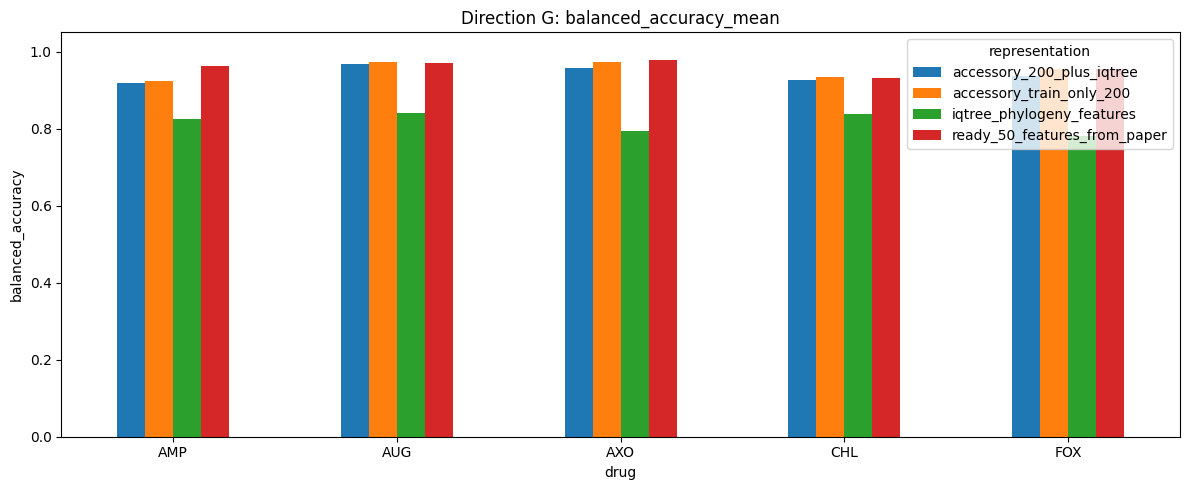

Saved: /content/salmonella_direction_G_iqtree/outputs/direction_G_balanced_accuracy_mean.png


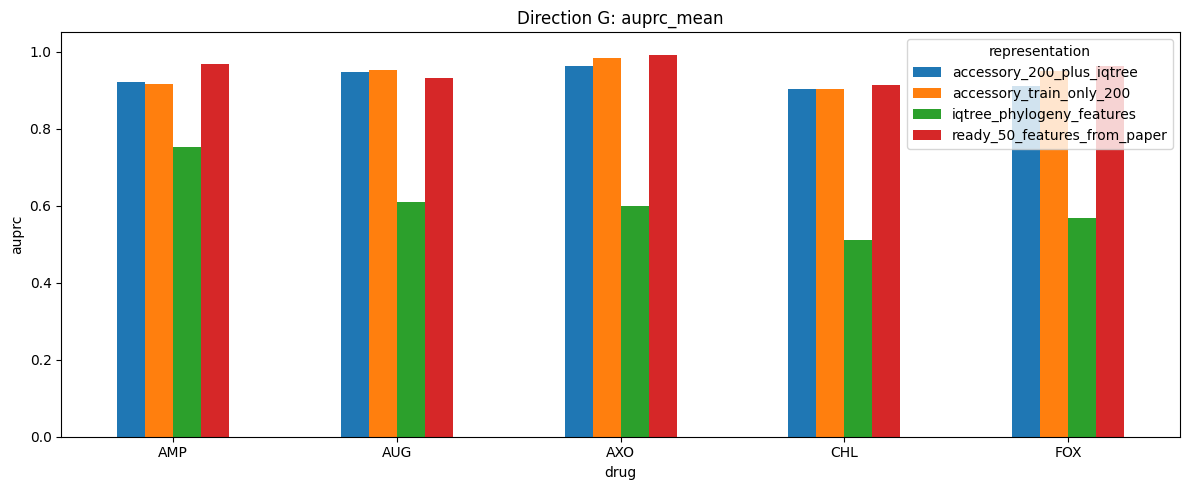

Saved: /content/salmonella_direction_G_iqtree/outputs/direction_G_auprc_mean.png


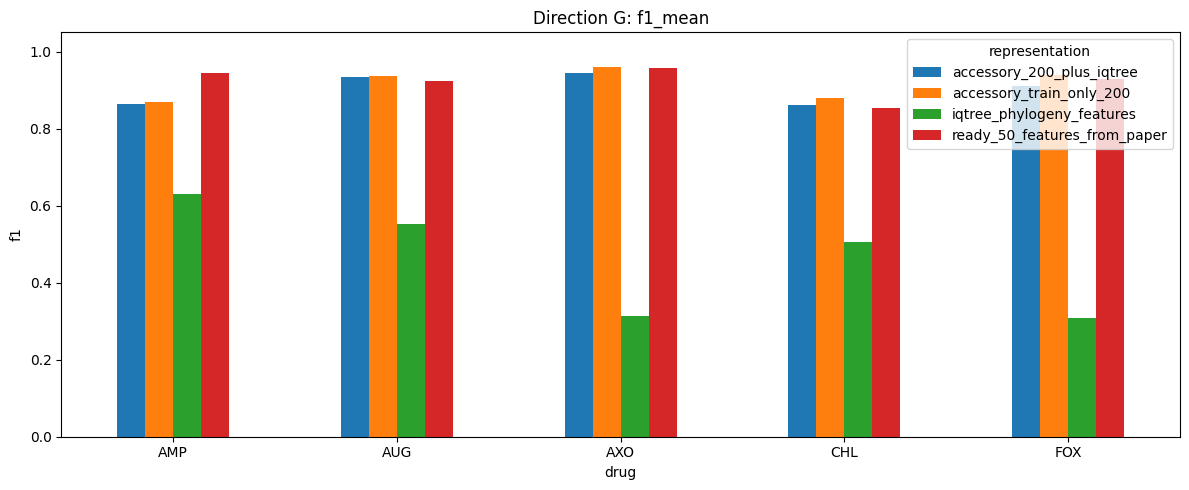

Saved: /content/salmonella_direction_G_iqtree/outputs/direction_G_f1_mean.png


In [ ]:
# =========================
# 15. Biểu đồ so sánh
# =========================

for metric in ["balanced_accuracy_mean", "auprc_mean", "f1_mean"]:
    pivot = summary.pivot_table(index="drug", columns="representation", values=metric)
    ax = pivot.plot(kind="bar", figsize=(12, 5))
    ax.set_title(f"Direction G: {metric}")
    ax.set_ylabel(metric.replace("_mean", ""))
    ax.set_ylim(0, 1.05)
    plt.xticks(rotation=0)
    plt.tight_layout()
    fig_path = OUT_DIR / f"direction_G_{metric}.png"
    plt.savefig(fig_path, dpi=180)
    plt.show()
    print("Saved:", fig_path)

In [ ]:
# =========================
# 16. Kết luận
# =========================

lines = []
lines.append("# Kết luận tự động — Direction G IQ-TREE")
lines.append("")
lines.append("## Mục tiêu")
lines.append("Kiểm tra xem việc bổ sung đặc trưng tiến hóa/lineage từ cây IQ-TREE có cải thiện dự đoán AMR so với chỉ dùng gen phụ hoặc 50 đặc trưng bài báo không.")
lines.append("")
lines.append("## Cấu hình")
lines.append(f"- Core SNP dùng để dựng cây: tối đa {MAX_SNPS_FOR_TREE} SNP có phương sai cao.")
lines.append(f"- Gen phụ: chọn {K_ACCESSORY} đặc trưng chỉ trên tập huấn luyện.")
lines.append(f"- Lặp {N_REPEATS} lần chia random stratified.")
lines.append("")
lines.append("## Kết quả tốt nhất theo balanced accuracy")
for _, row in best_bacc.iterrows():
    lines.append(f"- {row['drug']}: tốt nhất là {row['representation']}, balanced accuracy = {row['balanced_accuracy_mean']:.3f} ± {row['balanced_accuracy_std']:.3f}, AUPRC = {row['auprc_mean']:.3f} ± {row['auprc_std']:.3f}.")
lines.append("")
lines.append("## Kết quả tốt nhất theo AUPRC")
for _, row in best_auprc.iterrows():
    lines.append(f"- {row['drug']}: tốt nhất là {row['representation']}, balanced accuracy = {row['balanced_accuracy_mean']:.3f} ± {row['balanced_accuracy_std']:.3f}, AUPRC = {row['auprc_mean']:.3f} ± {row['auprc_std']:.3f}.")
lines.append("")
lines.append("## Cách diễn giải")
lines.append("- Nếu accessory_200_plus_iqtree thắng, thông tin lineage từ IQ-TREE có giúp tăng hiệu năng khi kết hợp với gen phụ.")
lines.append("- Nếu accessory_train_only_200 thắng, gen phụ vẫn là nguồn tín hiệu chính và phylogeny không giúp thêm nhiều trong random split.")
lines.append("- Nếu iqtree_phylogeny_features một mình cao, model có thể đang khai thác mạnh tín hiệu lineage; cần diễn giải cẩn thận.")
lines.append("- Nếu ready_50_features_from_paper thắng, bộ 50 đặc trưng của bài báo vẫn là baseline rất mạnh.")
lines.append("")
lines.append("## Lưu ý")
lines.append("Cây IQ-TREE được dựng từ core SNP của toàn bộ mẫu theo cách unsupervised, không dùng nhãn kháng thuốc. Nếu muốn đánh giá thật nghiêm ngặt cho dữ liệu mới, cần thêm bước đặt mẫu mới lên cây hoặc dựng cây trong từng fold.")

conclusion_text = "\n".join(lines)
print(conclusion_text)
with open(OUT_DIR / "AUTO_CONCLUSION_DIRECTION_G.md", "w") as f:
    f.write(conclusion_text)


# Kết luận tự động — Direction G IQ-TREE

## Mục tiêu
Kiểm tra xem việc bổ sung đặc trưng tiến hóa/lineage từ cây IQ-TREE có cải thiện dự đoán AMR so với chỉ dùng gen phụ hoặc 50 đặc trưng bài báo không.

## Cấu hình
- Core SNP dùng để dựng cây: tối đa 3000 SNP có phương sai cao.
- Gen phụ: chọn 200 đặc trưng chỉ trên tập huấn luyện.
- Lặp 10 lần chia random stratified.

## Kết quả tốt nhất theo balanced accuracy
- AMP: tốt nhất là ready_50_features_from_paper, balanced accuracy = 0.964 ± 0.017, AUPRC = 0.967 ± 0.017.
- AUG: tốt nhất là accessory_train_only_200, balanced accuracy = 0.974 ± 0.020, AUPRC = 0.952 ± 0.037.
- AXO: tốt nhất là ready_50_features_from_paper, balanced accuracy = 0.977 ± 0.025, AUPRC = 0.991 ± 0.012.
- CHL: tốt nhất là accessory_train_only_200, balanced accuracy = 0.933 ± 0.023, AUPRC = 0.903 ± 0.048.
- FOX: tốt nhất là accessory_train_only_200, balanced accuracy = 0.956 ± 0.023, AUPRC = 0.949 ± 0.035.

## Kết quả tốt nhất theo AUPRC
- AMP: tốt nhất là ready_50_

In [ ]:
# =========================
# 17. zip
# =========================

zip_path = BASE_DIR / "salmonella_direction_G_iqtree_outputs.zip"
if zip_path.exists():
    zip_path.unlink()
!cd "{BASE_DIR}" && zip -qr "{zip_path}" outputs
print("Đã nén:", zip_path)
print("Nếu muốn tải trong Colab, chạy:")
print(f"from google.colab import files; files.download('{zip_path}')")

Đã nén: /content/salmonella_direction_G_iqtree/salmonella_direction_G_iqtree_outputs.zip
Nếu muốn tải trong Colab, chạy:
from google.colab import files; files.download('/content/salmonella_direction_G_iqtree/salmonella_direction_G_iqtree_outputs.zip')
